# Neurolab · LIMINAL Heartbeat
## Помогает ли повторное уточнение модели?

Этот практикум обучает Neurolab на эмоциональных аннотациях английского текста,
сравнивает K=1 и K=5 с простыми методами и сохраняет полноценный пакет модели.
**Runtime → Run all. Достаточно CPU; платные API не нужны.**

Результат: обученные веса, базовые сравнения, три графика и проверка повторной загрузки.
V/A/D — оценки аннотаций текста, а не измерение состояния конкретного человека.

## 1. Подготовка
Код закреплён по версии. Набор EmoBank закреплён по commit и проверяется по хешу.
Установка и загрузка исходников требуют интернета. Версии библиотек попадут в отчёт.

In [1]:
import importlib.util
import os
from pathlib import Path
import subprocess
import sys

CODE_REF = "f6d48884efd86dc61327fa46002ed3093833eec9"
local_repo = os.environ.get("NEUROLAB_LOCAL_REPO")
if local_repo:
    repo = Path(local_repo).resolve()
else:
    base = Path("/content") if Path("/content").exists() else Path.cwd()
    repo = base / ("Neurolab-lab-" + CODE_REF[:12].replace("/", "-"))
    if not repo.exists():
        subprocess.run(["git", "clone", "--quiet", "--no-checkout",
                        "https://github.com/safal207/Neurolab.git", str(repo)], check=True)
    subprocess.run(["git", "-C", str(repo), "checkout", "--quiet", CODE_REF], check=True)
os.chdir(repo)
sys.path.insert(0, str(repo))
packages = ["torch", "numpy", "pandas", "sklearn", "matplotlib", "joblib", "tqdm", "ipywidgets"]
if any(importlib.util.find_spec(name) is None for name in packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "requirements-lab.txt"], check=True)
print("Neurolab готов. Результаты сохраняются в", repo / "artifacts")

Neurolab готов. Результаты сохраняются в /workspace/scratch/ae46edbceaa3/neurolab/artifacts


## 2. Параметры эксперимента
План сравнения фиксируется до результатов: seed 42, 3 000 строк train, 10 эпох,
одинаковые 64 текстовых признака, средний прогноз, Ridge, Neurolab K=1 и K=5.
Для полного train можно поставить max_train=0. Такой запуск создаёт новый результат.

Признаки TF-IDF → SVD → масштабирование обучаются только на train.
Память между независимыми текстами выключена; a=None, правильные ответы модель не получает.

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from neurolab.experiment import LabConfig, download_data, read_splits, run_experiment, predict_texts
from neurolab.lab_plots import plot_results

config = LabConfig(seed=42, max_train=3000, epochs=10, dim=64, iterations=(1, 5))
output_dir = Path("artifacts/neurolab-colab-run")
display(pd.Series(config.__dict__, name="Параметр").to_frame())

,Параметр
seed,42
max_train,3000
epochs,10
batch_size,128
dim,64
vocabulary,8000
learning_rate,0.001
iterations,"(1, 5)"


## 3. Данные и границы проверки
[EmoBank](https://github.com/JULIELab/EmoBank) содержит объединённые оценки
читателей и авторов. V — положительность, A — возбуждение, D — ощущение контроля.
Сырые оценки лежат на шкале 1–5; при обучении используется (оценка − 3) / 2.

Сохраняем официальные назначения train/dev/test. Точные совпадения текста
с предыдущими выборками исключаем из dev/test и показываем их количество.
Поэтому итоговая проверка относится к указанным подмножествам, а не всему corpus.

In [3]:
data_path = download_data()
splits, quality = read_splits(data_path, config)
display(pd.DataFrame({"официальные строки": quality["official_counts"],
                      "используемые строки": quality["used_counts"]}).loc[["train", "dev", "test"]])
print("Исключённые совпадения:", quality["exact_text_overlap_excluded"])

Исключённые совпадения: {'dev': 15, 'test': 16}


,официальные строки,используемые строки
train,8062,3000
dev,1000,985
test,1000,984


## 4. Обучение и итоговая проверка
Dev выбирает регуляризацию Ridge и лучшую эпоху каждой нейросети.
Веса для демонстрации выбираются по dev, а не по test.
MAE показана в исходных пунктах шкалы 1–5: **меньше — лучше**.

In [4]:
report = run_experiment(data_path, output_dir, config)
metrics = pd.DataFrame(report["test_metrics"])
display(metrics.round(4))
print("Сохранённая версия для демо:", report["selected_neural"])
print("Длительность вычислений, с:", report["elapsed_seconds"])

Сохранённая версия для демо: Neurolab K=5
Длительность вычислений, с: 8.05


,model,MAE_V,MAE_A,MAE_D,MAE_mean
0,Train mean,0.2427,0.1884,0.1569,0.1960
1,Ridge,0.2422,0.1853,0.1557,0.1944
2,Neurolab K=1,0.2470,0.1912,0.1582,0.1988
3,Neurolab K=5,0.2417,0.1865,0.1570,0.1951


## 5. Результаты на графиках
Первый график сравнивает ошибку на test. Второй показывает dev по эпохам
и отмечает выбранные веса. Третий сравнивает Neurolab с Ridge на тех же строках.
Интервалы — 95% парное пересэмплирование тестовых строк при одном seed обучения;
они не учитывают вариативность между несколькими обучениями.

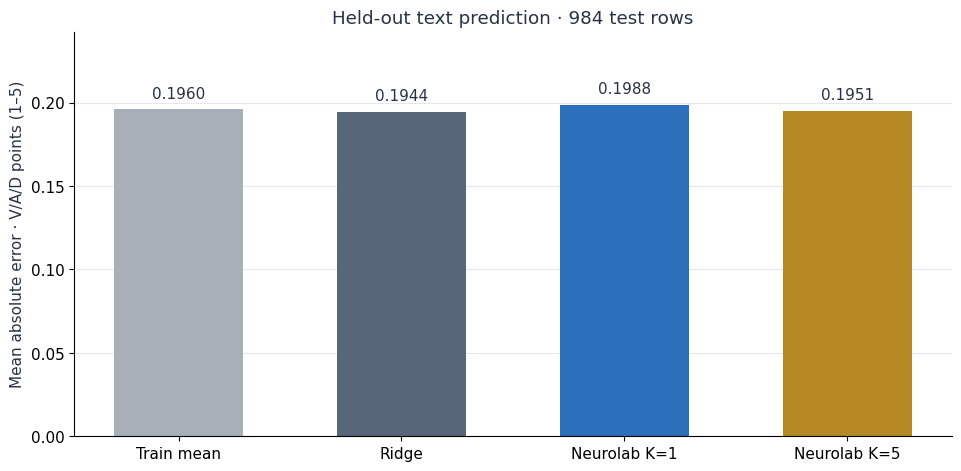

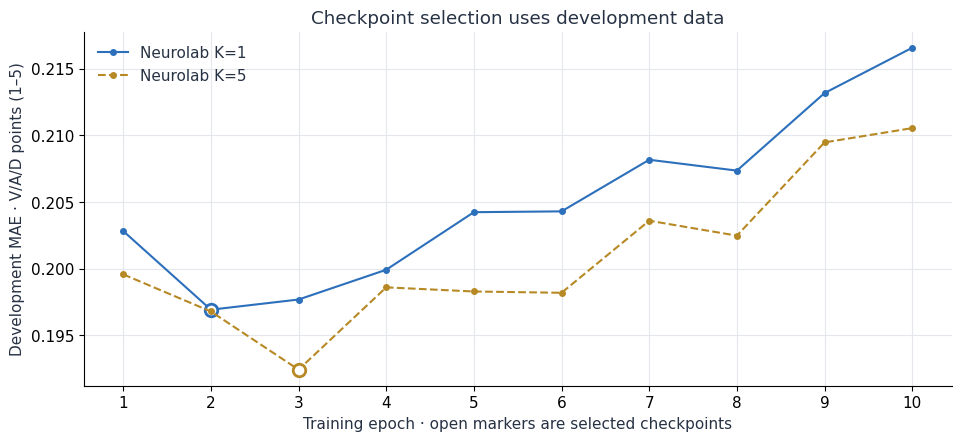

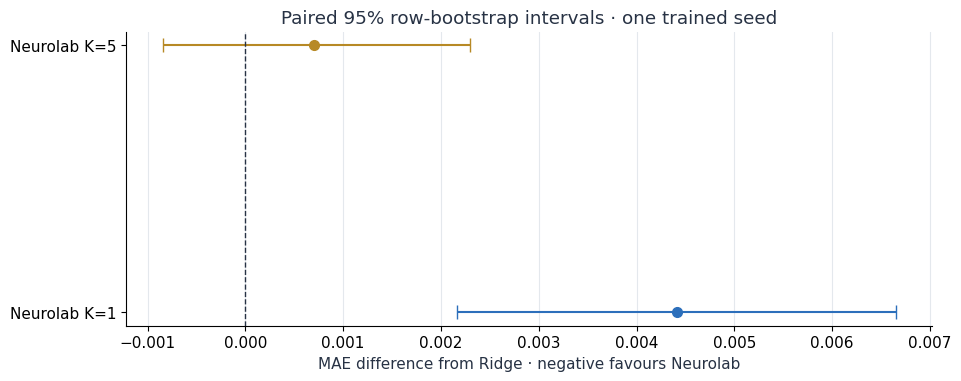

In [5]:
figures = plot_results(output_dir)
plt.show()

## 6. Вывод, который следует из этого запуска
Вывод ниже вычисляется по сохранённому отчёту. Преимущество на одном запуске
не переносится автоматически на другие данные, языки, признаки или обучение.

In [6]:
for name, comparison in report["paired_comparisons_to_ridge"].items():
    lower, upper = comparison["row_bootstrap_95pct"]
    if upper < 0:
        verdict = "ошибка ниже Ridge в этом эксперименте"
    elif lower > 0:
        verdict = "ошибка выше Ridge в этом эксперименте"
    else:
        verdict = "преимущество над Ridge не установлено"
    display(Markdown(f"**{name}:** {verdict}. ΔMAE={comparison['delta_MAE']:+.4f}; "
                     f"95% интервал по строкам [{lower:+.4f}, {upper:+.4f}]."))

**Neurolab K=1:** ошибка выше Ridge в этом эксперименте. ΔMAE=+0.0044; 95% интервал по строкам [+0.0022, +0.0066].

**Neurolab K=5:** преимущество над Ridge не установлено. ΔMAE=+0.0007; 95% интервал по строкам [-0.0008, +0.0023].

## 7. Один текст — три метода
Выберите пример или введите английское предложение в поле ниже и нажмите
**Сравнить модели**. Панель загружает сохранённые веса K=1/K=5 и Ridge;
повторно обучать модели для каждого текста не нужно.

Покрытие словаря описывает знакомые признаки, а не уверенность модели.
Примеры позволяют увидеть ошибки и близкие к среднему прогнозы.
Английский — язык этого эксперимента; язык введённого текста автоматически не определяется.

In [7]:
from neurolab.lab_demo import create_demo
display(create_demo(output_dir))

### Проверка повторной загрузки
Эта проверка сравнивает численные результаты после повторной загрузки с диска.

In [8]:
TEXTS = ["I am happy about this result.", "I am worried about tomorrow."]
predictions = predict_texts(output_dir, TEXTS)
display(predictions.round(3))
reloaded = predict_texts(output_dir, TEXTS)
np.testing.assert_allclose(predictions[["V", "A", "D"]], reloaded[["V", "A", "D"]], atol=1e-6)
print("Повторная загрузка сохранила прогнозы: OK")

Повторная загрузка сохранила прогнозы: OK


,text,V,A,D
0,I am happy about this result.,2.988,2.972,3.026
1,I am worried about tomorrow.,3.018,2.969,3.022


## 8. Сохранить пакет
ZIP содержит веса, словарь/SVD/масштабирование, численные прогнозы,
таблицы, графики и происхождение данных. В Colab архив скачивается на устройство.
Данные EmoBank лицензированы CC-BY-SA 4.0; код Neurolab — MIT.
Источник: Sven Buechel и Udo Hahn, [EACL 2017](https://aclanthology.org/E17-2092/).

In [9]:
import shutil
archive = Path(shutil.make_archive(str(output_dir), "zip", root_dir=output_dir))
print("Готовый архив:", archive)
try:
    from google.colab import files
except ImportError:
    print("Готовый архив:", archive)
else:
    files.download(str(archive))

Готовый архив: /workspace/scratch/ae46edbceaa3/neurolab/artifacts/neurolab-colab-run.zip
Готовый архив: /workspace/scratch/ae46edbceaa3/neurolab/artifacts/neurolab-colab-run.zip


## Дальше
Повторите заранее согласованный эксперимент с несколькими seed и более сильными
фиксированными признаками. Механизм памяти проверяйте отдельно на упорядоченных
последовательностях. Текущий практикум проверяет независимые английские тексты.